# Experiments
Thin driver notebook for PipeDream / GPD / SGD comparisons.


In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /Users/ilini/Desktop/ivan/study/pipeDream_experiments/pipedream_project


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from src.objectives.quadratic import QuadraticObjective
from src.schedulers.pipedream_1f1b import PipeDream1F1BScheduler, print_schedule, plot_schedule
from src.methods.pipedream import PipeDreamMethod
from src.methods.gpd import GPDMethod
from src.methods.sgd import SGDMethod
from src.experiments.runner import ExperimentRunner
from src.experiments.compare_methods import compare_methods
from src.plotting.convergence import plot_block_update_comparison
from src.utils.batching import build_training_batch_schedule
from src.state.timeline import num_microbatches_from_timeline

In [3]:
def exact_quadratic_fstar(objective: QuadraticObjective) -> float:
    """
    Exact optimal value for the quadratic least-squares objective.
    Works even if noise is present.
    """
    w_star, *_ = np.linalg.lstsq(objective.X, objective.y, rcond=None)
    residual = objective.X @ w_star - objective.y
    return float(0.5 * np.mean(residual ** 2))


def estimate_empirical_block_grad_bound(
    objective: QuadraticObjective,
    stage_weights,
    max_batches: int | None = None,
) -> float:
    """
    Practical proxy for G in the theorem:
    max block-gradient norm over the available minibatches at the current iterate.

    Important:
    the theorem assumes a global bound G, which is not available naturally for
    unconstrained quadratic optimization over all R^d. So this is an empirical
    surrogate used only for the experimental theoretical-LR reference.
    """
    batches = objective.get_batches()
    if max_batches is not None:
        batches = batches[:max_batches]

    G = 0.0
    for Xb, yb in batches:
        pred = np.zeros(Xb.shape[0])
        for s, sl in enumerate(objective.stage_slices):
            pred += Xb[:, sl] @ stage_weights[s]
        residual = pred - yb

        for s, sl in enumerate(objective.stage_slices):
            grad_s = Xb[:, sl].T @ (residual / len(yb))
            G = max(G, float(np.linalg.norm(grad_s)))
    return G


def gpd_theoretical_stepsize(
    objective: QuadraticObjective,
    init_stage_weights,
    K: int,
    G_proxy: float | None = None,
    f_star: float | None = None,
) -> tuple[float, dict]:
    """
    gamma = min{1/L, sqrt( 2(f(w0)-f*) / (L G^2 K) )}

    Returns gamma and diagnostic pieces used to compute it.
    """
    L = objective.smoothness_constant
    f0 = objective.full_objective(init_stage_weights)

    if f_star is None:
        f_star = exact_quadratic_fstar(objective)

    if G_proxy is None:
        G_proxy = estimate_empirical_block_grad_bound(objective, init_stage_weights)

    second = np.sqrt(2.0 * max(f0 - f_star, 0.0) / (L * (G_proxy ** 2) * K + 1e-30))
    gamma = min(1.0 / L, second)

    return gamma, {
        "L": L,
        "f0": f0,
        "f_star": f_star,
        "G_proxy": G_proxy,
        "one_over_L": 1.0 / L,
        "sqrt_term": second,
    }


def score_trace_at_budget(trace, K_budget: int) -> float:
    curve = trace.block_update_objective
    if curve is None or len(curve) == 0:
        raise ValueError("Trace has no block_update_objective.")
    idx = min(K_budget, len(curve)) - 1
    return float(curve[idx])


def make_pd_method(
    lr: float,
    timeline,
    training_batch_indices,
    init_stage_weights,
    name: str | None = None,
):
    return PipeDreamMethod(
        timeline=timeline,
        learning_rate=lr,
        training_batch_indices=training_batch_indices,
        init_stage_weights=init_stage_weights,
        name=name or f"PipeDream lr={lr:.3e}",
    )


def make_gpd_method(
    lr: float,
    K_budget: int,
    delta: int,
    training_batch_indices,
    init_stage_weights,
    seed: int,
    name: str | None = None,
):
    return GPDMethod(
        num_iterations=K_budget,
        learning_rate=lr,
        delta=delta,
        seed=seed,
        stage_sampling="uniform",
        batch_sampling="uniform",
        stale_sampling="uniform",
        training_batch_indices=training_batch_indices,
        init_stage_weights=init_stage_weights,
        name=name or f"GPD lr={lr:.3e}",
    )


def make_sgd_method(
    lr: float,
    K_budget: int,
    num_stages: int,
    training_batch_indices,
    init_stage_weights,
    seed: int,
    name: str | None = None,
):
    num_sgd_iterations = int(np.ceil(K_budget / num_stages))
    return SGDMethod(
        num_iterations=num_sgd_iterations,
        learning_rate=lr,
        seed=seed,
        batch_sampling="uniform",
        training_batch_indices=training_batch_indices,
        init_stage_weights=init_stage_weights,
        name=name or f"SGD lr={lr:.3e}",
    )


def run_trials(objective, method_factory, seeds):
    traces = []
    for seed in seeds:
        method = method_factory(seed)
        trace = method.run(objective)
        traces.append(trace)
    return traces


def aggregate_block_curves(traces, K_budget: int):
    curves = []
    for tr in traces:
        curve = tr.block_update_objective
        if curve is None:
            raise ValueError(f"{tr.method_name} has no block_update_objective.")
        if len(curve) < K_budget:
            raise ValueError(f"Curve too short: len={len(curve)}, required {K_budget}")
        curves.append(curve[:K_budget])
    curves = np.stack(curves, axis=0)
    return {
        "mean": curves.mean(axis=0),
        "std": curves.std(axis=0),
        "final_mean": float(curves[:, -1].mean()),
        "final_std": float(curves[:, -1].std()),
        "all": curves,
    }


def aggregate_time_curves(traces):
    curves = []
    for tr in traces:
        curve = tr.objective_trace
        if curve is None or len(curve) == 0:
            raise ValueError(f"{tr.method_name} has no objective_trace.")
        curves.append(curve)

    T = min(len(c) for c in curves)
    curves = np.stack([c[:T] for c in curves], axis=0)

    return {
        "mean": curves.mean(axis=0),
        "std": curves.std(axis=0),
        "final_mean": float(curves[:, -1].mean()),
        "final_std": float(curves[:, -1].std()),
        "all": curves,
    }

def sweep_learning_rates(
    objective,
    method_name: str,
    learning_rates,
    method_factory_builder,
    seeds,
    K_budget: int,
):
    results = {}

    for lr in learning_rates:
        traces = run_trials(
            objective=objective,
            method_factory=lambda seed, lr=lr: method_factory_builder(lr, seed),
            seeds=seeds,
        )
        agg = aggregate_block_curves(traces, K_budget=K_budget)
        results[float(lr)] = {
            "traces": traces,
            "mean_curve": agg["mean"],
            "std_curve": agg["std"],
            "final_mean": agg["final_mean"],
            "final_std": agg["final_std"],
        }

    best_lr = min(results.keys(), key=lambda lr: results[lr]["final_mean"])
    return {
        "method_name": method_name,
        "results": results,
        "best_lr": best_lr,
        "best_curve": results[best_lr]["mean_curve"],
        "best_std": results[best_lr]["std_curve"],
    }


def plot_lr_sweep_curves(
    sweep_result,
    title: str,
    reference_lr: float | None = None,
    reference_label: str | None = None,
    log_scale: bool = False,
):
    plt.figure(figsize=(9, 5))
    eps = 1e-16

    for lr, info in sorted(sweep_result["results"].items(), key=lambda x: x[0]):
        y = np.maximum(info["mean_curve"], eps) if log_scale else info["mean_curve"]
        label = f"lr={lr:.3e}"
        if np.isclose(lr, sweep_result["best_lr"]):
            label += "  [best]"
            lw = 2.8
        elif reference_lr is not None and np.isclose(lr, reference_lr):
            label += f"  [{reference_label}]"
            lw = 2.8
        else:
            lw = 1.4

        if log_scale:
            plt.semilogy(y, label=label, linewidth=lw)
        else:
            plt.plot(y, label=label, linewidth=lw)

    plt.xlabel("number of block updates")
    plt.ylabel("full objective")
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.02, 1.0), loc="upper left")
    plt.tight_layout(rect=[0, 0, 0.8, 1])
    plt.show()


def plot_lr_sweep_summary(
    sweep_result,
    title: str,
    reference_lr: float | None = None,
    reference_label: str | None = None,
):
    lrs = np.array(sorted(sweep_result["results"].keys()))
    means = np.array([sweep_result["results"][lr]["final_mean"] for lr in lrs])
    stds = np.array([sweep_result["results"][lr]["final_std"] for lr in lrs])

    plt.figure(figsize=(7, 4))
    plt.errorbar(lrs, means, yerr=stds, marker="o")
    plt.xscale("log")
    plt.xlabel("learning rate")
    plt.ylabel("final objective at fixed budget")
    plt.title(title)

    if reference_lr is not None:
        plt.axvline(reference_lr, linestyle="--", linewidth=1.5, label=reference_label)
        plt.legend()

    plt.tight_layout()
    plt.show()

In [4]:
# problem setup
num_stages = 10
num_microbatches = 100
batch_size = 32
seed = 0

num_examples = batch_size * num_microbatches

objective = QuadraticObjective.synthetic(
    num_examples=num_examples,
    num_parameters=64,
    num_stages=num_stages,
    batch_size=batch_size,
    seed=seed,
    noise_std=0.0,
)

scheduler = PipeDream1F1BScheduler(noam=num_stages)
timeline = scheduler.generate(num_stages=num_stages, num_microbatches=num_microbatches)

init_stage_weights = objective.initial_stage_weights(mode="zeros", seed=0)

# fixed PipeDream batch order for fairness across PipeDream LR sweeps
num_dataset_batches = len(objective.get_batches())

training_batch_indices = build_training_batch_schedule(
    num_dataset_batches=num_dataset_batches,
    num_microbatches=num_microbatches,
    shuffle_each_epoch=False,
    seed=seed + 1,
)

print("num_dataset_batches =", num_dataset_batches)
print("effective epochs    =", num_microbatches / num_dataset_batches)
print("first training batches =", training_batch_indices[:min(20, len(training_batch_indices))])

# common block-update budget:
# PipeDream naturally defines it
pd_probe = make_pd_method(
    lr=1e-3,
    timeline=timeline,
    training_batch_indices=training_batch_indices,
    init_stage_weights=init_stage_weights,
    name="PipeDream probe",
).run(objective)

K_budget = len(pd_probe.block_update_objective)
print("K_budget =", K_budget)

# useful constants
L = objective.smoothness_constant
gamma_sgd_reference = 1.0 / L

# for GPD theory-inspired step
delta_gpd = num_stages-1
gamma_gpd_theory, gpd_theory_info = gpd_theoretical_stepsize(
    objective=objective,
    init_stage_weights=init_stage_weights,
    K=K_budget,
)

print("L =", L)
print("1/L =", gamma_sgd_reference)
print("GPD theoretical gamma =", gamma_gpd_theory)
print("GPD theory diagnostics =", gpd_theory_info)

num_dataset_batches = 100
effective epochs    = 1.0
first training batches = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
K_budget = 1000
L = 1.3108771315769157
1/L = 0.7628480014729169
GPD theoretical gamma = 0.021066295066949327
GPD theory diagnostics = {'L': 1.3108771315769157, 'f0': 31.003457929415973, 'f_star': 8.397571958607908e-29, 'G_proxy': 10.32406924720713, 'one_over_L': 0.7628480014729169, 'sqrt_term': np.float64(0.021066295066949327)}


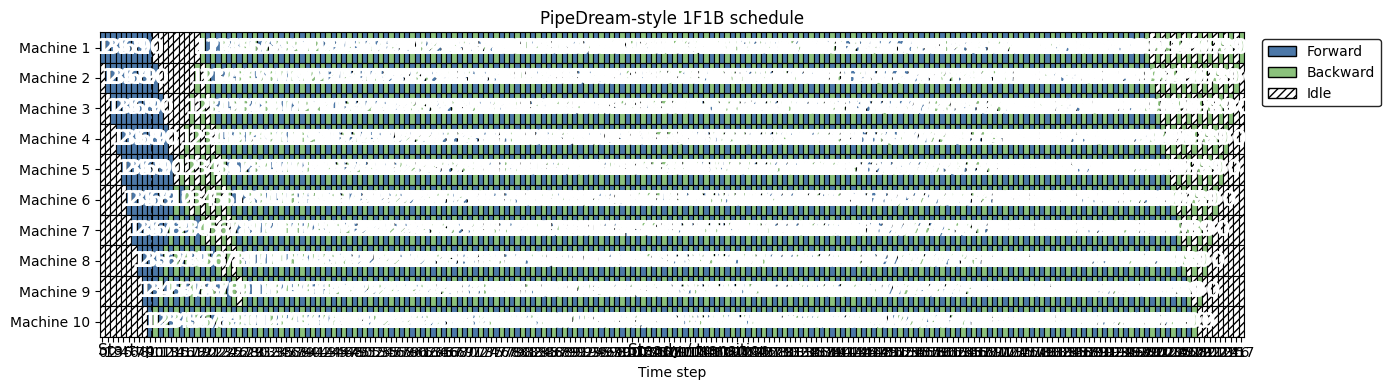

In [5]:
fig, ax = plot_schedule(timeline, startup_boundary=num_stages)
plt.show()

In [19]:
num_lr_points = 30
gamma_grid = np.linspace(0.01 / L, 0.3 / L, num_lr_points)

print("L =", L)
print("gamma min =", gamma_grid[0])
print("gamma max =", gamma_grid[-1])
print("1/L =", 1.0 / L)

pd_lrs = gamma_grid.copy()

pd_sweep = sweep_learning_rates(
    objective=objective,
    method_name="PipeDream",
    learning_rates=pd_lrs,
    method_factory_builder=lambda lr, seed: make_pd_method(
        lr=lr,
        timeline=timeline,
        training_batch_indices=training_batch_indices,
        init_stage_weights=init_stage_weights,
        name=f"PipeDream lr={lr:.6e}",
    ),
    seeds=[0],
    K_budget=K_budget,
)

print("Best PipeDream lr =", pd_sweep["best_lr"])
print("Best PipeDream lr * L =", pd_sweep["best_lr"] * L)

L = 1.3108771315769157
gamma min = 0.007628480014729169
gamma max = 0.22885440044187505
1/L = 0.7628480014729169
Best PipeDream lr = 0.06865632013256251
Best PipeDream lr * L = 0.08999999999999998


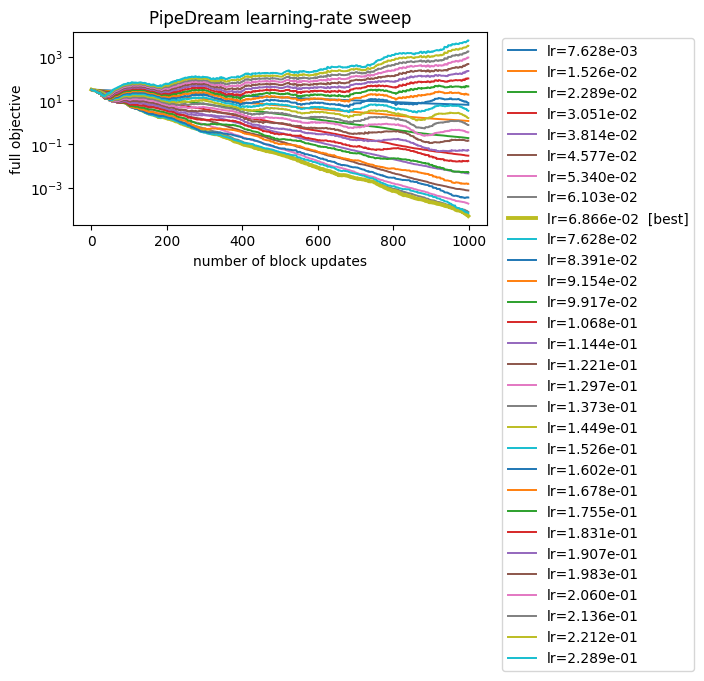

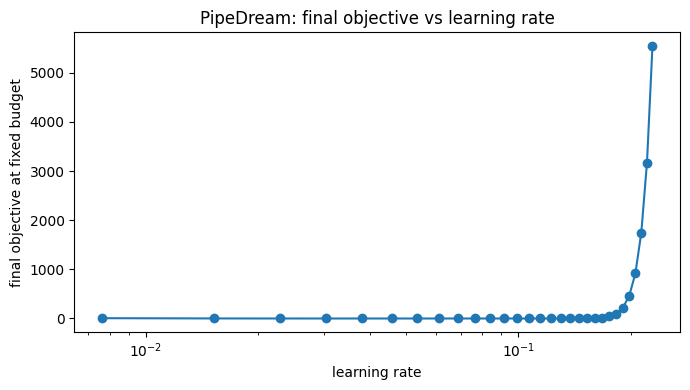

In [20]:
plot_lr_sweep_curves(
    pd_sweep,
    title="PipeDream learning-rate sweep",
    log_scale=True,
)

plot_lr_sweep_summary(
    pd_sweep,
    title="PipeDream: final objective vs learning rate",
)

In [8]:
gamma_grid = np.linspace(0.1 / L, 1.0 / L, num_lr_points)

gpd_lrs = np.unique(np.sort(np.concatenate([
    gamma_grid,
    np.array([gamma_gpd_theory]),
])))

gpd_sweep = sweep_learning_rates(
    objective=objective,
    method_name="GPD",
    learning_rates=gpd_lrs,
    method_factory_builder=lambda lr, seed: make_gpd_method(
        lr=lr,
        K_budget=K_budget,
        delta=delta_gpd,
        training_batch_indices=training_batch_indices,
        init_stage_weights=init_stage_weights,
        seed=seed,
        name=f"GPD lr={lr:.6e}",
    ),
    seeds=list(range(10)),
    K_budget=K_budget,
)

print("Best GPD lr =", gpd_sweep["best_lr"])
print("Best GPD lr * L =", gpd_sweep["best_lr"] * L)
print("Theoretical GPD lr =", gamma_gpd_theory)
print("Theoretical GPD lr * L =", gamma_gpd_theory * L)

Best GPD lr = 0.26568154534056765
Best GPD lr * L = 0.3482758620689656
Theoretical GPD lr = 0.021066295066949327
Theoretical GPD lr * L = 0.027615324450315462


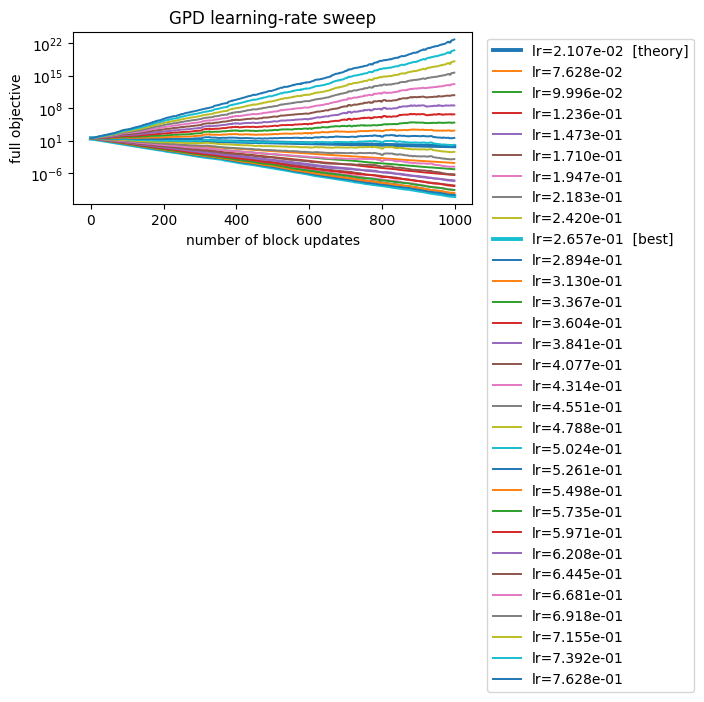

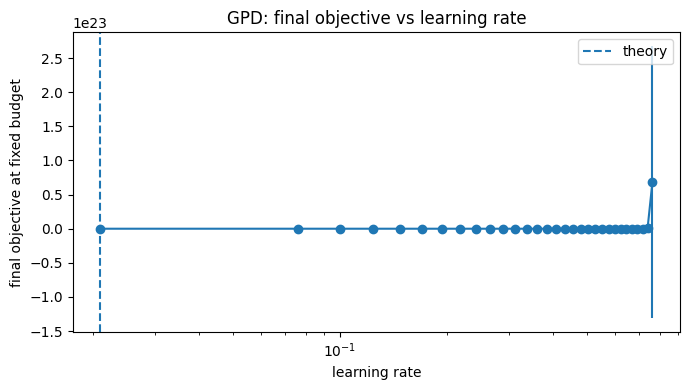

In [9]:
plot_lr_sweep_curves(
    gpd_sweep,
    title="GPD learning-rate sweep",
    reference_lr=gamma_gpd_theory,
    reference_label="theory",
    log_scale=True,
)

plot_lr_sweep_summary(
    gpd_sweep,
    title="GPD: final objective vs learning rate",
    reference_lr=gamma_gpd_theory,
    reference_label="theory",
)

In [21]:
gamma_sgd_reference = 1.0 / L

gamma_grid = np.linspace(0.1 / L, 1.2 / L, num_lr_points)

sgd_lrs = np.unique(np.sort(np.concatenate([
    gamma_grid,
    np.array([gamma_sgd_reference]),
])))

sgd_sweep = sweep_learning_rates(
    objective=objective,
    method_name="SGD",
    learning_rates=sgd_lrs,
    method_factory_builder=lambda lr, seed: make_sgd_method(
        lr=lr,
        K_budget=K_budget,
        num_stages=num_stages,
        training_batch_indices=training_batch_indices,
        init_stage_weights=init_stage_weights,
        seed=seed,
        name=f"SGD lr={lr:.6e}",
    ),
    seeds=list(range(10)),
    K_budget=K_budget,
)

print("Best SGD lr =", sgd_sweep["best_lr"])
print("Best SGD lr * L =", sgd_sweep["best_lr"] * L)
print("Reference SGD lr = 1/L =", gamma_sgd_reference)

Best SGD lr = 0.33670532478804605
Best SGD lr * L = 0.4413793103448276
Reference SGD lr = 1/L = 0.7628480014729169


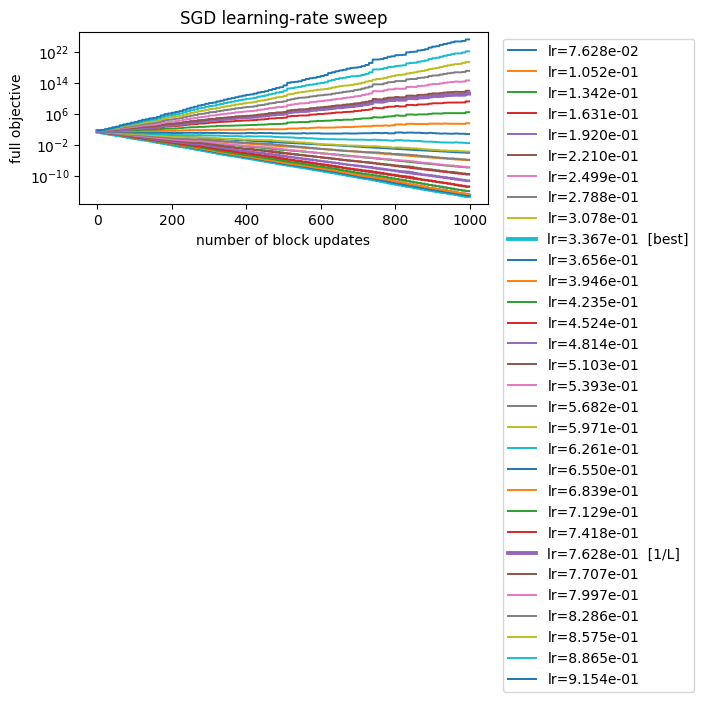

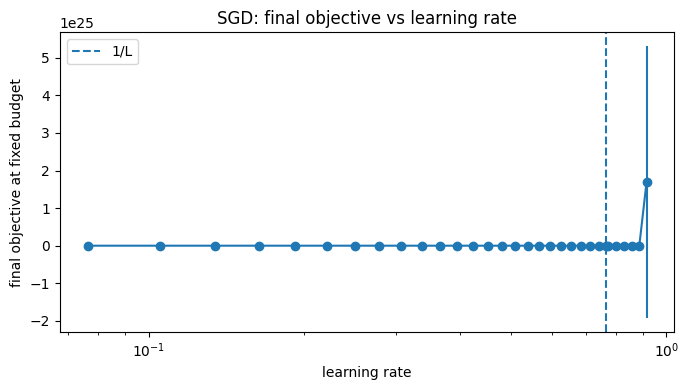

In [22]:
plot_lr_sweep_curves(
    sgd_sweep,
    title="SGD learning-rate sweep",
    reference_lr=gamma_sgd_reference,
    reference_label="1/L",
    log_scale=True,
)

plot_lr_sweep_summary(
    sgd_sweep,
    title="SGD: final objective vs learning rate",
    reference_lr=gamma_sgd_reference,
    reference_label="1/L",
)

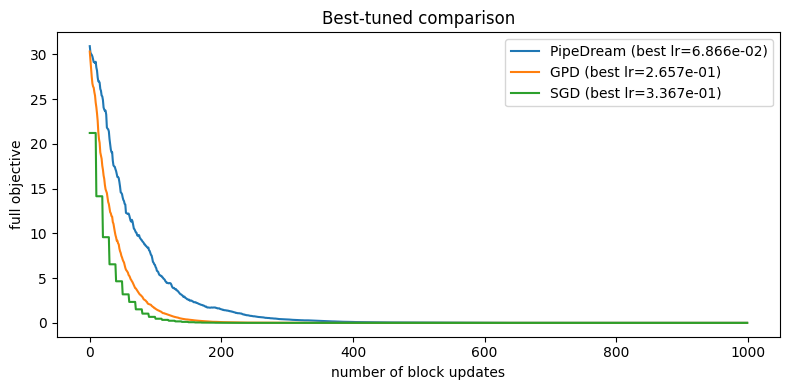

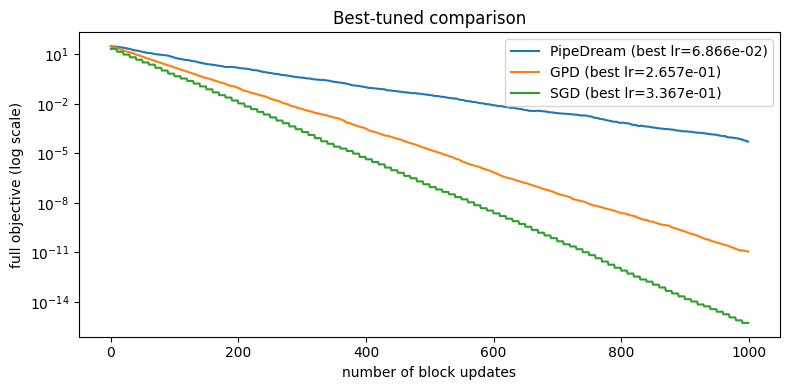

In [23]:
best_pd_curve = pd_sweep["best_curve"]
best_gpd_curve = gpd_sweep["best_curve"]
best_sgd_curve = sgd_sweep["best_curve"]

T = max(len(best_pd_curve), len(best_gpd_curve), len(best_sgd_curve))

plt.figure(figsize=(8, 4))
plt.plot(best_pd_curve[:T], label=f"PipeDream (best lr={pd_sweep['best_lr']:.3e})")
plt.plot(best_gpd_curve[:T], label=f"GPD (best lr={gpd_sweep['best_lr']:.3e})")
plt.plot(best_sgd_curve[:T], label=f"SGD (best lr={sgd_sweep['best_lr']:.3e})")
plt.xlabel("number of block updates")
plt.ylabel("full objective")
plt.title("Best-tuned comparison")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
eps = 1e-16
plt.semilogy(np.maximum(best_pd_curve[:T], eps), label=f"PipeDream (best lr={pd_sweep['best_lr']:.3e})")
plt.semilogy(np.maximum(best_gpd_curve[:T], eps), label=f"GPD (best lr={gpd_sweep['best_lr']:.3e})")
plt.semilogy(np.maximum(best_sgd_curve[:T], eps), label=f"SGD (best lr={sgd_sweep['best_lr']:.3e})")
plt.xlabel("number of block updates")
plt.ylabel("full objective (log scale)")
plt.title("Best-tuned comparison")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# Use the same seeds you used for the sweeps
time_seeds = list(range(10))

pd_best_traces_time = run_trials(
    objective=objective,
    method_factory=lambda seed: make_pd_method(
        lr=pd_sweep["best_lr"],
        timeline=timeline,
        training_batch_indices=training_batch_indices,
        init_stage_weights=init_stage_weights,
        name=f"PipeDream best lr={pd_sweep['best_lr']:.3e}",
    ),
    seeds=time_seeds,
)

gpd_best_traces_time = run_trials(
    objective=objective,
    method_factory=lambda seed: make_gpd_method(
        lr=gpd_sweep["best_lr"],
        K_budget=K_budget,
        delta=delta_gpd,
        training_batch_indices=training_batch_indices,
        init_stage_weights=init_stage_weights,
        seed=seed,
        name=f"GPD best lr={gpd_sweep['best_lr']:.3e}",
    ),
    seeds=time_seeds,
)

sgd_best_traces_time = run_trials(
    objective=objective,
    method_factory=lambda seed: make_sgd_method(
        lr=sgd_sweep["best_lr"],
        K_budget=K_budget,
        num_stages=num_stages,
        training_batch_indices=training_batch_indices,
        init_stage_weights=init_stage_weights,
        seed=seed,
        name=f"SGD best lr={sgd_sweep['best_lr']:.3e}",
    ),
    seeds=time_seeds,
)

pd_time = aggregate_time_curves(pd_best_traces_time)
gpd_time = aggregate_time_curves(gpd_best_traces_time)
sgd_time = aggregate_time_curves(sgd_best_traces_time)

In [14]:
len(pd_time["mean"])

219

In [15]:
len(gpd_time["mean"])

1001

In [16]:
len(sgd_time["mean"])

101

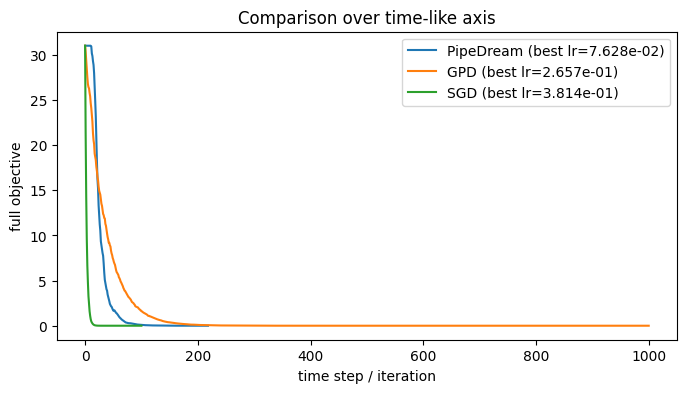

In [17]:
T_time = min(len(pd_time["mean"]), len(gpd_time["mean"]), len(sgd_time["mean"]))
x = np.arange(T_time)

plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(pd_time["mean"])), pd_time["mean"], label=f"PipeDream (best lr={pd_sweep['best_lr']:.3e})")
plt.plot(np.arange(len(gpd_time["mean"])), gpd_time["mean"], label=f"GPD (best lr={gpd_sweep['best_lr']:.3e})")
plt.plot(np.arange(len(sgd_time["mean"])), sgd_time["mean"], label=f"SGD (best lr={sgd_sweep['best_lr']:.3e})")
plt.xlabel("time step / iteration")
plt.ylabel("full objective")
plt.title("Comparison over time-like axis")
plt.legend()
plt.show()

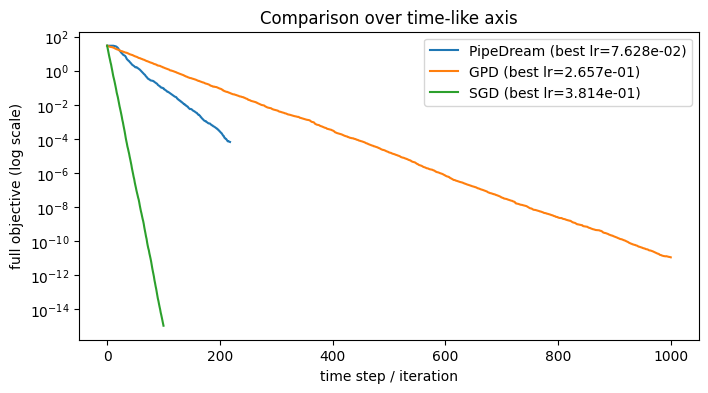

In [18]:
eps = 1e-16
T_time = min(len(pd_time["mean"]), len(gpd_time["mean"]), len(sgd_time["mean"]))
x = np.arange(T_time)

plt.figure(figsize=(8, 4))
plt.semilogy(np.arange(len(pd_time["mean"])), np.maximum(pd_time["mean"], eps), label=f"PipeDream (best lr={pd_sweep['best_lr']:.3e})")
plt.semilogy(np.arange(len(gpd_time["mean"])), np.maximum(gpd_time["mean"], eps), label=f"GPD (best lr={gpd_sweep['best_lr']:.3e})")
plt.semilogy(np.arange(len(sgd_time["mean"])), np.maximum(sgd_time["mean"], eps), label=f"SGD (best lr={sgd_sweep['best_lr']:.3e})")
plt.xlabel("time step / iteration")
plt.ylabel("full objective (log scale)")
plt.title("Comparison over time-like axis")
plt.legend()
plt.show()